In [102]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [103]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import GridSearchCV
import joblib

In [61]:
data = pd.read_csv("university_admission.csv")

In [62]:
print(data.head())

   Serial No.  pre_term_test  final_term_test  university_rating  \
0           1            337              118                  4   
1           2            324              107                  4   
2           3            316              104                  3   
3           4            322              110                  3   
4           5            314              103                  2   

   sop_strength  lor_score  cgpa  has_research_exp  admission_chance  
0           4.5        4.5  9.65                 1              0.92  
1           4.0        4.5  8.87                 1              0.76  
2           3.0        3.5  8.00                 1              0.72  
3           3.5        2.5  8.67                 1              0.80  
4           2.0        3.0  8.21                 0              0.65  


In [63]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Serial No.         500 non-null    int64  
 1   pre_term_test      500 non-null    int64  
 2   final_term_test    500 non-null    int64  
 3   university_rating  500 non-null    int64  
 4   sop_strength       500 non-null    float64
 5   lor_score          500 non-null    float64
 6   cgpa               500 non-null    float64
 7   has_research_exp   500 non-null    int64  
 8   admission_chance   500 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 35.3 KB
None


In [64]:
print(data.describe())

       Serial No.  pre_term_test  final_term_test  university_rating  \
count  500.000000     500.000000       500.000000         500.000000   
mean   250.500000     316.472000       107.192000           3.114000   
std    144.481833      11.295148         6.081868           1.143512   
min      1.000000     290.000000        92.000000           1.000000   
25%    125.750000     308.000000       103.000000           2.000000   
50%    250.500000     317.000000       107.000000           3.000000   
75%    375.250000     325.000000       112.000000           4.000000   
max    500.000000     340.000000       120.000000           5.000000   

       sop_strength  lor_score        cgpa  has_research_exp  admission_chance  
count    500.000000  500.00000  500.000000        500.000000         500.00000  
mean       3.374000    3.48400    8.576440          0.560000           0.72174  
std        0.991004    0.92545    0.604813          0.496884           0.14114  
min        1.000000    1.00

In [65]:
data = data.drop('Serial No.', axis=1)

In [66]:
data = data.rename(columns={
    'pre_term_test': 'GRE_Score',
    'final_term_test': 'TOEFL_Score',
    'university_rating': 'University_Rating',
    'sop_strength': 'SOP',
    'lor_score': 'LOR',
    'cgpa': 'CGPA',
    'has_research_exp': 'Research',
    'admission_chance': 'Chance_of_Admit'
})

In [112]:
print("--- Data after cleaning and renaming ---")
print(data.head())

--- Data after cleaning and renaming ---
   GRE_Score  TOEFL_Score  University_Rating  SOP  LOR  CGPA  Research  \
0        337          118                  4  4.5  4.5  9.65         1   
1        324          107                  4  4.0  4.5  8.87         1   
2        316          104                  3  3.0  3.5  8.00         1   
3        322          110                  3  3.5  2.5  8.67         1   
4        314          103                  2  2.0  3.0  8.21         0   

   Chance_of_Admit  
0             0.92  
1             0.76  
2             0.72  
3             0.80  
4             0.65  


In [68]:
features = ['GRE_Score', 'TOEFL_Score', 'University_Rating', 'SOP', 'LOR', 'CGPA', 'Research']

In [69]:
X = data[features]

In [70]:
y = data['Chance_of_Admit']

In [71]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.2, random_state = 42)

In [72]:
print("--- Data Splitting ---")
print(f"X_train (features) shape: {X_train.shape}")
print(f"X_test (features) shape: {X_test.shape}")
print(f"y_train (label) shape: {y_train.shape}")
print(f"y_test (label) shape: {y_test.shape}")

--- Data Splitting ---
X_train (features) shape: (400, 7)
X_test (features) shape: (100, 7)
y_train (label) shape: (400,)
y_test (label) shape: (100,)


In [73]:
model = LinearRegression()

In [74]:
model.fit(X_train, y_train)
print("Model trained successfully!")

Model trained successfully!


In [75]:
y_pred = model.predict(X_test)

In [76]:
r2 = r2_score(y_test, y_pred)
print(f"R-squared (R²): {r2:.4f}")

R-squared (R²): 0.8188


In [77]:
mae = mean_absolute_error(y_test, y_pred)
print(f"Mean Absolute Error (MAE): {mae:.4f}")

Mean Absolute Error (MAE): 0.0427


In [78]:
model_rf = RandomForestRegressor(n_estimators=100, random_state=42)

In [79]:
model_filename = 'admission_model.joblib'

In [80]:
model_rf.fit(X_train, y_train)
print("Model trained successfully!")

Model trained successfully!


In [81]:
y_pred_rf = model_rf.predict(X_test)

In [82]:
print("--- Random Forest Model Evaluation ---")
r2_rf = r2_score(y_test, y_pred_rf)
print(f"R-squared (R²): {r2_rf:.4f}")

--- Random Forest Model Evaluation ---
R-squared (R²): 0.7875


In [83]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
print(f"Mean Absolute Error (MAE): {mae_rf:.4f}")

Mean Absolute Error (MAE): 0.0438


In [84]:
print("--- Model Comparison ---")
print(f"Linear Regression R²: {r2:.4f}") 
print(f"Random Forest R²:     {r2_rf:.4f}")

--- Model Comparison ---
Linear Regression R²: 0.8188
Random Forest R²:     0.7875


In [85]:
model_ridge = Ridge(alpha=1.0, random_state=42)

In [86]:
model_ridge.fit(X_train, y_train)
y_pred_ridge = model_ridge.predict(X_test)
print("Ridge model trained and evaluated.")

Ridge model trained and evaluated.


In [87]:
model_lasso = Lasso(alpha=0.001, random_state=42)

In [88]:
print("--- Training the Lasso model... ---")
model_lasso.fit(X_train, y_train)
y_pred_lasso = model_lasso.predict(X_test)
print("Lasso model trained and evaluated.\n")

--- Training the Lasso model... ---
Lasso model trained and evaluated.



In [89]:
r2_ridge = r2_score(y_test, y_pred_ridge)
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)

In [90]:
r2_lasso = r2_score(y_test, y_pred_lasso)
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)

In [91]:
print("--- Final Model R-squared (R²) Scores ---")
print(f"1. Linear Regression: {r2:.4f}")   # From cell 1
print(f"2. Ridge Regression:  {r2_ridge:.4f}")
print(f"3. Lasso Regression:  {r2_lasso:.4f}")
print(f"4. Random Forest:     {r2_rf:.4f}")

--- Final Model R-squared (R²) Scores ---
1. Linear Regression: 0.8188
2. Ridge Regression:  0.8180
3. Lasso Regression:  0.8138
4. Random Forest:     0.7875


In [92]:
model_tune = Ridge()

In [93]:
param_grid = {
    'alpha': np.logspace(-2, 1, 100)  # 100 values from 0.01 to 10
}

In [94]:
grid_search = GridSearchCV(
    estimator=model_tune, 
    param_grid=param_grid, 
    scoring='r2', 
    cv=5, 
    n_jobs=-1
)

In [95]:
grid_search.fit(X_train, y_train)

,estimator,Ridge()
,param_grid,{'alpha': array([ 0.01 ... 10. ])}
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,alpha,0.9326033468832199


In [96]:
print("Tuning complete!")

Tuning complete!


In [97]:
print(f"Best Alpha found: {grid_search.best_params_['alpha']:.4f}")
print(f"Best R² score (from cross-validation): {grid_search.best_score_:.4f}")

Best Alpha found: 0.9326
Best R² score (from cross-validation): 0.8080


In [98]:
best_ridge_model = grid_search.best_estimator_

In [100]:
y_pred_tuned = best_ridge_model.predict(X_test)
r2_tuned = r2_score(y_test, y_pred_tuned)

In [101]:
print("--- Tuned Model vs. Original ---")
print(f"1. Linear Regression (Original): {r2:.4f}")
print(f"2. Tuned Ridge Regression:    {r2_tuned:.4f}")

--- Tuned Model vs. Original ---
1. Linear Regression (Original): 0.8188
2. Tuned Ridge Regression:    0.8180


In [104]:
coefficients = model.coef_

In [105]:
feature_importance = pd.DataFrame({'Feature': features, 'Importance': coefficients})

In [106]:
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

C:\Users\madhu\AppData\Local\Temp\ipykernel_4492\2256313120.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


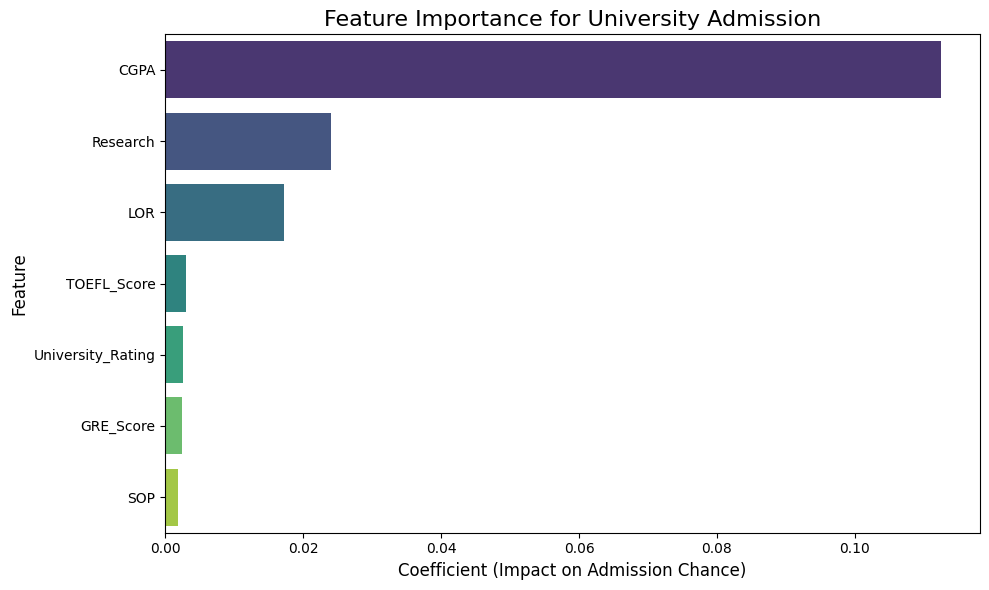

In [111]:
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Importance', 
    y='Feature', 
    data=feature_importance, 
    palette='viridis' # A nice color scheme
)
plt.title('Feature Importance for University Admission', fontsize=16)
plt.xlabel('Coefficient (Impact on Admission Chance)', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout() # Adjusts plot for a good fit
plt.show()

In [22]:
joblib.dump(model, model_filename)

['admission_model.joblib']